# Full-FORCE demonstration
Eli Pollock, Jazayeri Lab, MIT Brain and Cognitive Sciences

The following demonstration is based on the full-FORCE algorithm described in [DePasquale et al. 2017](https://arxiv.org/abs/1710.03070)

Thanks to Brian DePasquale for providing example code. For MATLAB demo, see [https://bitbucket.org/briandepasquale/full_force_learning/]. 

First, we create a function that will output our desired inputs, targets, and hints:

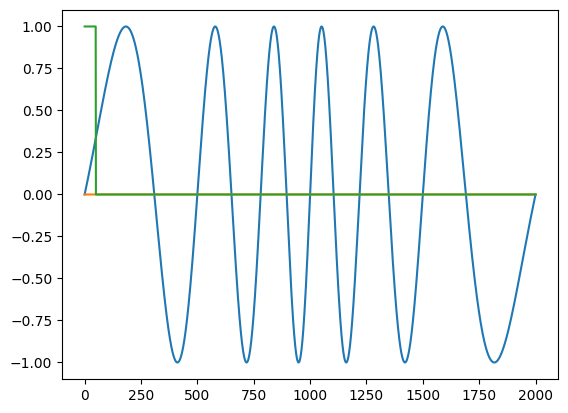

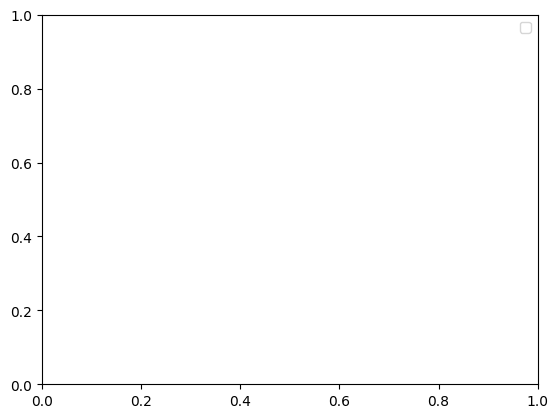

In [1]:
#%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
import time

def fullforce_oscillation_test(dt, showplots=0):
    dt_per_s = round(1/dt)
    
    # From the paper, and the online demo:
    t = np.expand_dims(np.linspace(0,2,2*dt_per_s+1),1)
    omega = np.zeros((2*dt_per_s+1,1))
    omega = np.linspace(2*np.pi, 6*np.pi, 1*dt_per_s+1)
    targ = np.zeros((2*dt_per_s+1,1))
    targ[0:(1*dt_per_s+1),0] = np.sin(t[0:(1*dt_per_s+1),0]*omega)
    targ[1*dt_per_s:(2*dt_per_s+1)] = -np.flipud(targ[0:(1*dt_per_s+1)])
    
    # A simpler example: just a sine wave
    '''
    t = np.expand_dims(np.linspace(0,2,2*dt_per_s+1),1)
    omega = np.ones((2*dt_per_s+1,1)) * 4 *np.pi
    targ = np.sin(t*omega)
    '''
    
    # A slightly harder example: sum of sine waves
    '''
    t = np.expand_dims(np.linspace(0,2,2*dt_per_s+1),1)
    omega = np.ones((2*dt_per_s+1,1)) * 4 *np.pi
    targ = np.sin(t*2*omega) * np.sin(t*omega/4)
    '''
    
    inp = np.zeros(targ.shape)
    inp[0:round(0.05*dt_per_s),0] = np.ones((round(0.05*dt_per_s)))
    hints = np.zeros(targ.shape)

    if showplots == 1:
        plt.figure()
        plt.plot(targ)
        plt.plot(hints)
        plt.plot(inp)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    
    return inp, targ, hints

fullforce_oscillation_test(dt=0.001,showplots=1);

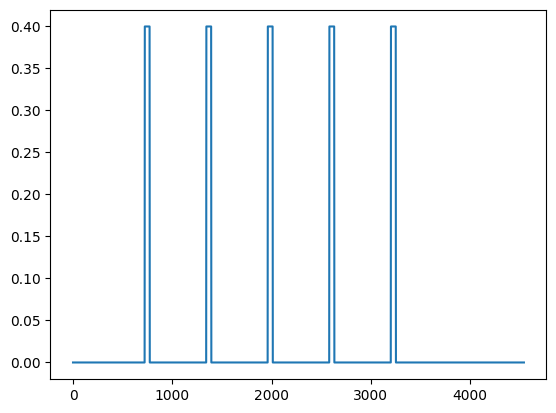

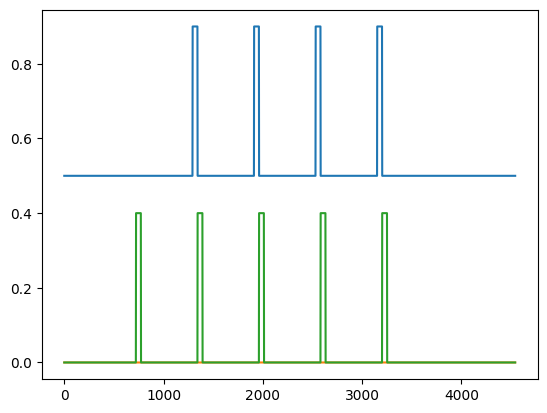

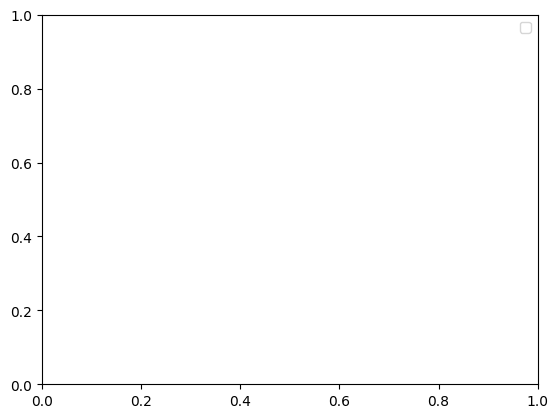

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

def random_pulses(dt, showplots = 0):
    n_events = 5
    hint = 'nohint'
    period = 0.5+.15*2*(np.random.uniform()-.5);
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint

def trial_pulse_prediction(dt, period, n_events, ITI, hint):
    output_offset = -0.5
    pulse_width = 0.05 # 0.05
    pulse_height = 0.02 / pulse_width
    output_timeshift = -pulse_width
    pulse_samples = np.round(pulse_width/dt).astype('int')
    
    n_timepoints = np.round((period*n_events+ITI)/dt).astype('int')
    
    
    timepoints = np.arange(0, n_timepoints)*dt

    
    fin = np.zeros((n_timepoints,1))
    fout = np.zeros((n_timepoints,1))
    
    fin[ np.mod(timepoints- ITI/2, period) < pulse_width ,0] = pulse_height
    
    fin[ timepoints < ITI/2 ,0] = 0
    fin[ timepoints > ITI/2 + period*n_events,0] = 0
    plt.plot(fin)
    
    fout = fin - output_offset
    
    fout[timepoints < ITI/2+pulse_width,0] = -output_offset
    fout[0:-1-pulse_samples]=fout[pulse_samples:-1]
    
    # desired output signals and hint signals
    fhint = np.zeros(fin.shape)
    

    return fin, fout, fhint

random_pulses(dt=0.001,showplots=1)


def specific_pulse(dt, showplots = 0, period = 0.4):
    n_events = 5
    hint = 'nohint'
    #period = 0.7 
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    #print(period)
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint


Below, we can train and test the network using the FF_Demo module. The key component is the RNN object class, which has activity and weights as attributes as methods that allow for training, running, and testing the network on arbitrary tasks. Open up the module file to see how RLS is implemented.

Here, I create a parameter dictionary, hand-tune some of them, instantiate an RNN, train it with full-FORCE, and then test it. You can see where the algorithm spends most of its time with %lprun. It should only take a couple of minutes to get good training results.

Note that FF_Demo requires numpy, scipy, and matplotlib, but that's it! 

In [ ]:
import importlib
import FF_Demo
importlib.reload(FF_Demo)
#%load_ext line_profiler

p = FF_Demo.create_parameters(dt=0.001)
p['g'] = 1.5 # From paper
p['ff_num_batches'] = 10
p['ff_trials_per_batch'] = 10
p['test_init_trials']=5
p['bias_scale'] = 0.7


(D_inputs, D_targs, D_hints) = random_pulses(dt=p['dt'])[0:3]

rnn = FF_Demo.RNN(p,1,1)

rnn.train(random_pulses, monitor_training=1)

#With line_profiler:
# %lprun -f rnn.train rnn.train(fullforce_oscillation_test, monitor_training=1)


rnn.test(specific_pulse)

Initializing...
Training network...
Batch 1 of 10, 10 trials: 
........

## The training statistics include an "error ratio" that is the ratio of the error after the update to the error before the update. It should converge to 1, meaning that the network cannot do any better.

The error magnitude is the just the norm of the error. That should decrease to close to 0.

The weights norm is, as one would expect, the norm of all weights. That should converge on some constant value as the weights stabilize.

In [ ]:
#rnn.test(multi_period_demo)


In [ ]:
error_to_plot = []
for item in np.arange(0.2,0.8,0.05):
    x = rnn.test(specific_pulse, period = item)
    error_to_plot.append(x[0][0])

plt.figure()
plt.plot(np.arange(0.2,0.8,0.05), error_to_plot)
plt.show()
#print(error_to_plot)

In [ ]:
import pickle

filename = "model5-10-10-0.7-bias"
pickle.dump(rnn, open(filename, 'wb'))


Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0407262
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0318798
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0309146
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0275247
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0174213
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.017337
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0156663
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0149599
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0115365
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0173973
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0203053
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0305777
Initializing.....
Testing: 10 trials
..........
Normalized error: 0.0267723


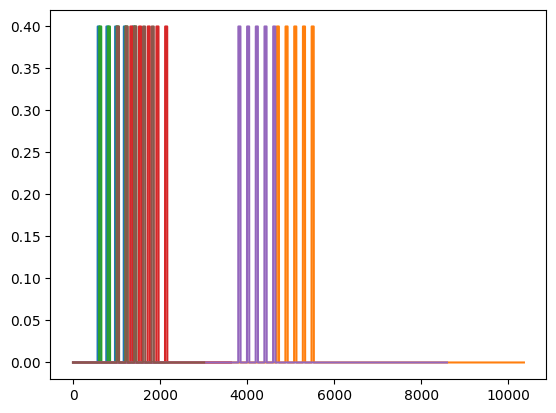

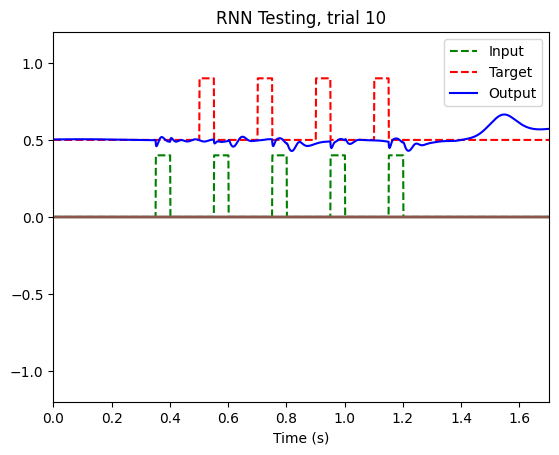

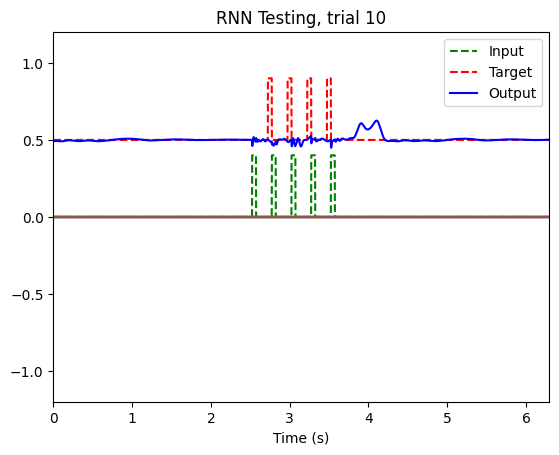

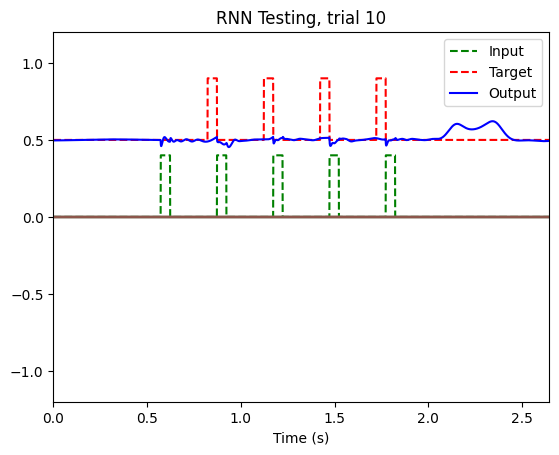

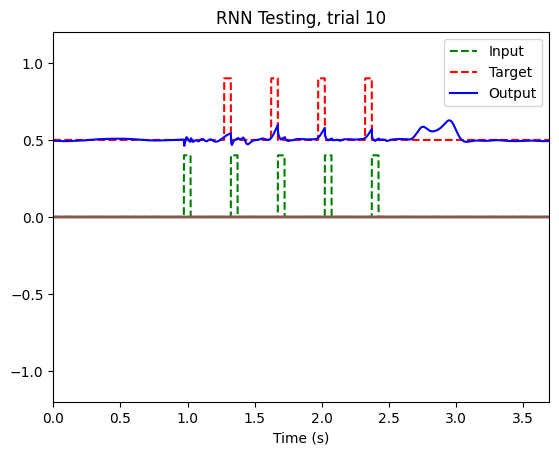

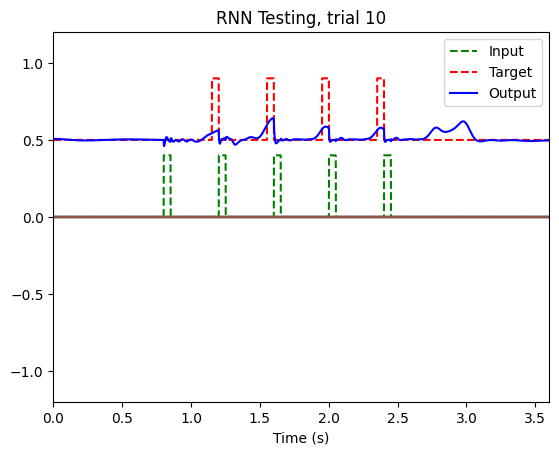

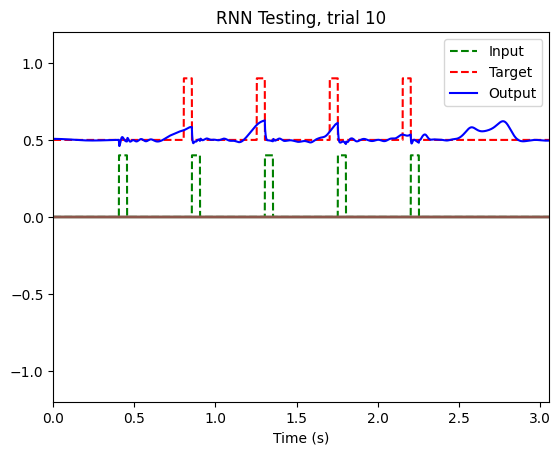

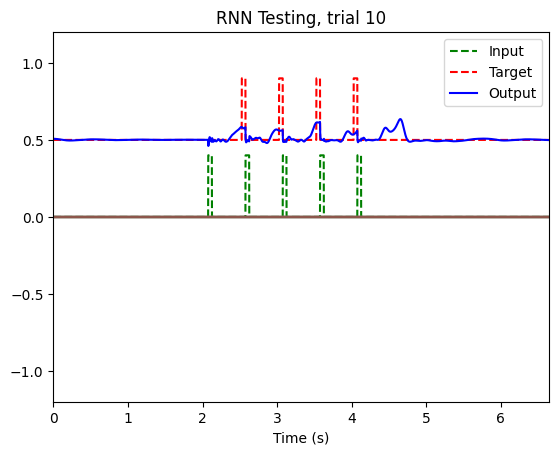

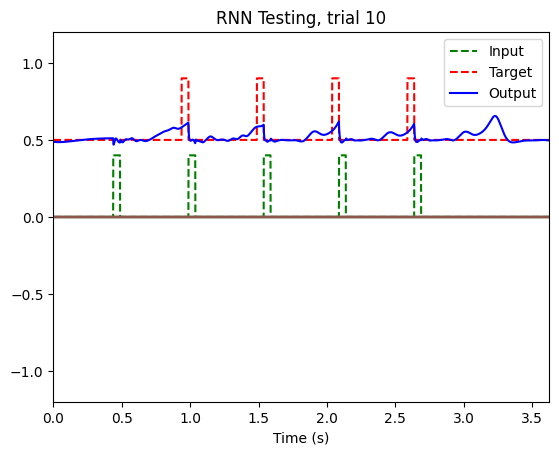

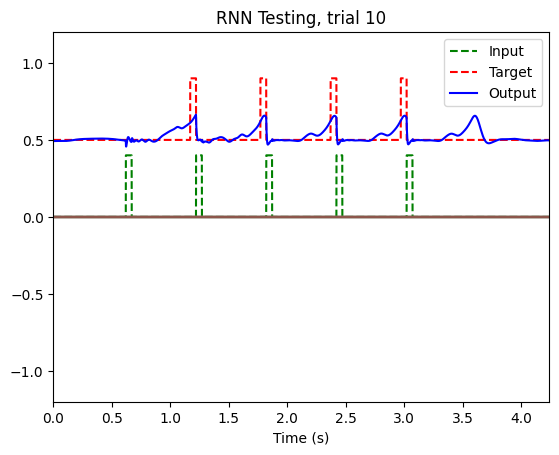

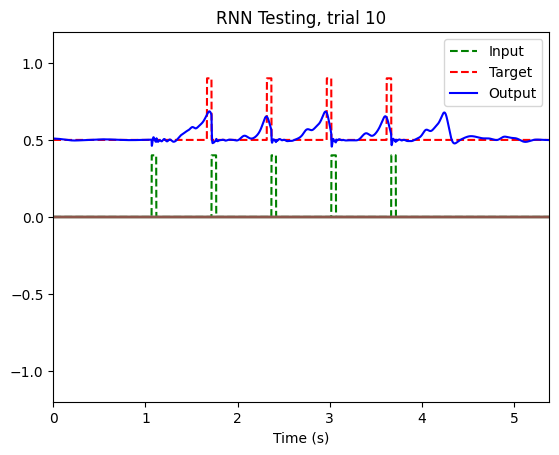

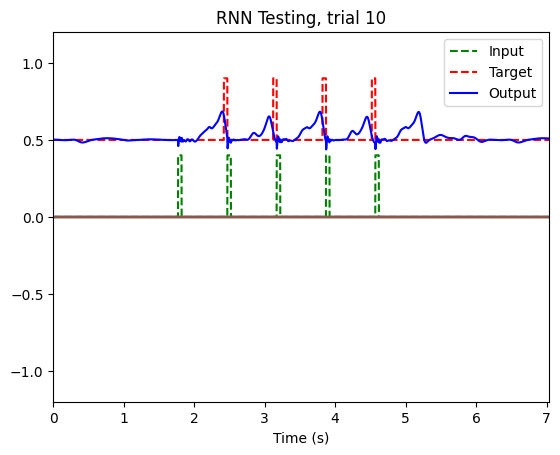

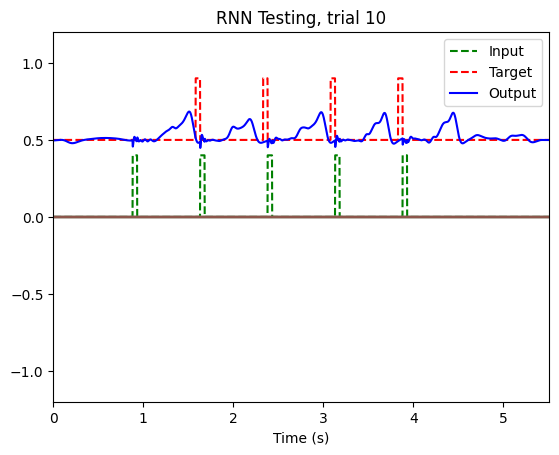

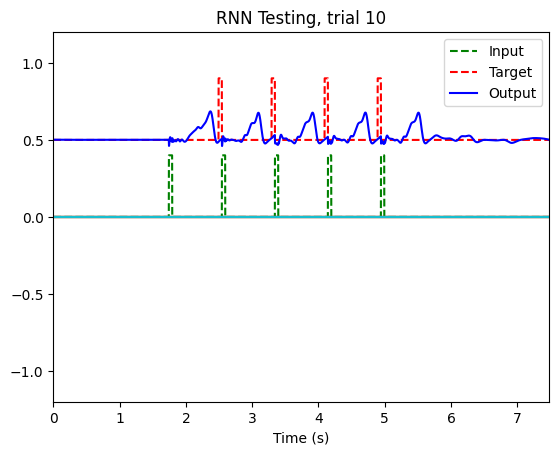

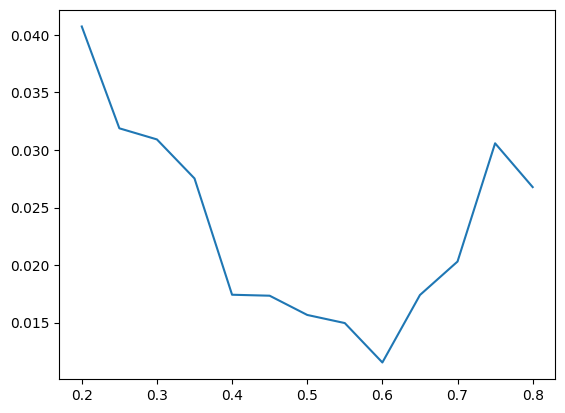

In [12]:
loaded_model = pickle.load(open("model4-20-20-0.3-bias",'rb'))
error_to_plot = []
for item in np.arange(0.2,0.8,0.05):
    x = loaded_model.test(specific_pulse, period = item)
    error_to_plot.append(x[0][0])

plt.figure()
plt.plot(np.arange(0.2,0.8,0.05), error_to_plot)
plt.show()
#print(error_to_plot)